In [9]:
import fitsio
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

In [10]:
data_dir = Path("./data/")

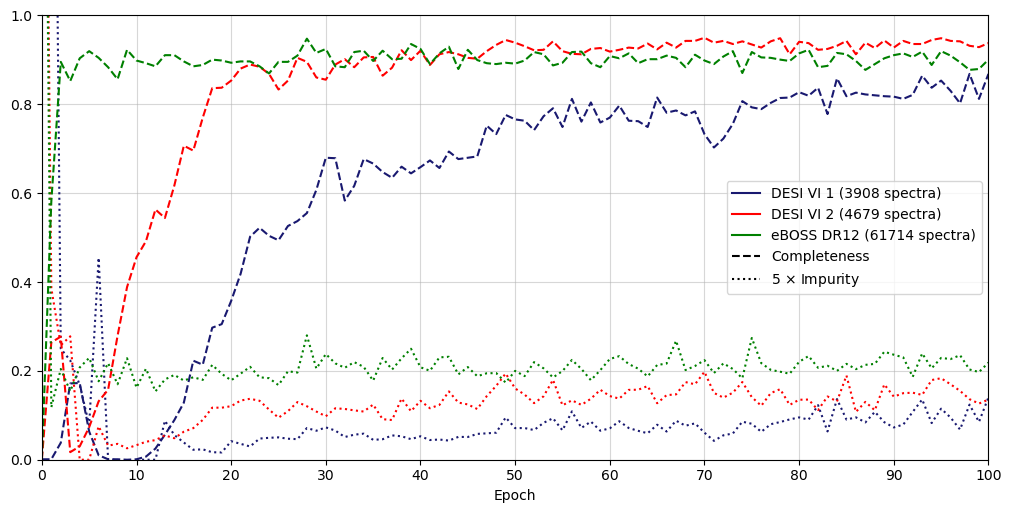

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), layout="constrained")

# Original model
with fitsio.FITS(data_dir / "train_fuji+guadalupe_v1_linear_6_layers_hist.fits") as h:
    d_pur = h[1].read(columns="purity")
    d_com = h[1].read(columns="completeness")

    ax.plot(5 * (1 - d_pur), "#191970", ls="dotted")
    ax.plot(d_com, "--", color="#191970")
    
    ax.plot([], [], label="DESI VI 1 (3908 spectra)", c="#191970")
    
with fitsio.FITS(data_dir / "train_fuji+guadalupe_v2_linear_6_layers_hist.fits") as h:
    d_pur = h[1].read(columns="purity")
    d_com = h[1].read(columns="completeness")
    
    ax.plot(5 * (1 - d_pur), "r", ls="dotted")
    ax.plot(d_com, "--", color="r")
    
    ax.plot([], [], label="DESI VI 2 (4679 spectra)", c="r")

with fitsio.FITS(data_dir / "train_dr16_linear_hist.fits") as h:
    d_pur = h[1].read(columns="purity")
    d_com = h[1].read(columns="completeness")

    ax.plot(5 * (1 - d_pur), "g", ls="dotted")
    ax.plot(d_com, "--", color="g")
    
    ax.plot([], [], label="eBOSS DR12 (61714 spectra)", c="g")
    
ax.set(ylim=(0, 1), xlim=(0, 100))

ax.plot([], [], label="Completeness", c="k", ls="dashed")
ax.plot([], [], label="5 $\\times$ Impurity", c="k", ls="dotted")


ax.grid(alpha=0.5)
ax.legend()

plt.xlabel("Epoch")
plt.xticks(ticks=np.arange(0, 110, 10))
plt.savefig("plots/purcom_dr12vdesi.pdf", bbox_inches="tight")